In [1]:
from PIL import Image
import numpy as np
from PIL import ImageChops
from PIL import ImageStat as stat
import matplotlib.pyplot as plt
from random import randint

# Zad 1

In [2]:
from PIL import Image

# Ścieżka do przesłanego pliku
file_path = 'im4.bmp'

# Otwieranie obrazu i sprawdzanie właściwości
image = Image.open(file_path)
image_mode = image.mode  # Tryb obrazu
image_size = image.size  # Rozmiar obrazu
pixel_value = image.getpixel((50, 100)) if image_size[0] > 50 and image_size[1] > 100 else None

image_mode, image_size, pixel_value

('RGB', (195, 210), (3, 15, 25))

In [3]:
# image = Image.open('im1.bmp')
# image.size
# image.mode
# pixel_value = image.getpixel((50, 100))
# pixel_value

In [4]:
dane_obrazka = np.asarray(image)
dane_obrazka.shape

(210, 195, 3)

# Zad 2

# Zad 3

In [5]:
tab = np.loadtxt("tab2.txt", dtype=np.bool_)
tab

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

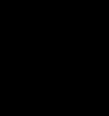

In [6]:
tab = np.loadtxt("tab2.txt", dtype=np.int_)

height, width = tab.shape  
image = Image.new('1', (width, height)) 
image

In [7]:
tab.shape

(116, 109)

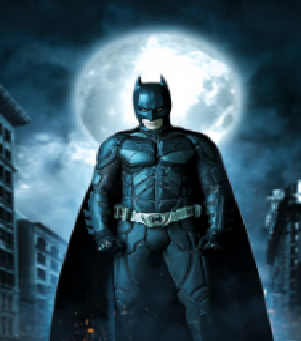

In [8]:
zad3 = Image.open("batman2.png")
zad3

In [9]:
with open("tab2.txt", "r") as file:
    tab_array = []
    for line in file:
        # Usuwamy wszystkie niecyfrowe znaki (np. spacje, znaki nowej linii)
        clean_line = ''.join(filter(str.isdigit, line.strip()))  # Zostawiamy tylko cyfry
        tab_array.append([int(pixel) for pixel in clean_line])  # Konwersja na listę 0 i 1

tab_array = np.array(tab_array)
tab_array

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

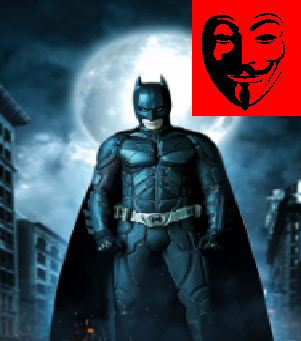

In [10]:
import numpy as np
from PIL import Image

file_path = "tab2.txt"
with open(file_path, "r") as file:
    tab_array = []
    for line in file:
        clean_line = ''.join(filter(str.isdigit, line.strip()))  
        tab_array.append([int(pixel) for pixel in clean_line])  

tab_array = np.array(tab_array)

tab_image = Image.fromarray((tab_array * 255).astype(np.uint8)) 

batman_path = "batman2.png"
batman_image = Image.open(batman_path).convert("RGB")

tab_w, tab_h = tab_image.size
batman_w, batman_h = batman_image.size

tab_image_rgb = Image.new("RGB", tab_image.size)
for x in range(tab_w):
    for y in range(tab_h):
        color = (255, 0, 0) if tab_array[y, x] == 1 else (0, 0, 0)  
        tab_image_rgb.putpixel((x, y), color)

paste_position = (batman_w - tab_w, 0)
batman_image.paste(tab_image_rgb, paste_position)

output_path = "final_image.png"
batman_image.save(output_path)

batman_image

# Zad 4

In [11]:
from PIL import ImageStat as stat
from PIL import ImageChops

def porownaj_obrazy(image1 :Image, image2: Image):
    im1_tab = np.asarray(image1)
    im2_tab = np.asarray(image2)
    
    im1_stat = stat.Stat(image1)
    im2_stat = stat.Stat(image2)
    difference = {
        'mode':(image1.mode == image2.mode),
        'size': (image1.size == image2.size),
        'format':(image1.format == image2.format),
        'extrema':(im1_stat.extrema == im2_stat.extrema),
        'count':(im1_stat.count == im2_stat.count),
        'mean':(im1_stat.mean == im2_stat.mean),
        'median':(im1_stat.median == im2_stat.median),
        'stddev':(im1_stat.stddev == im2_stat.stddev),
        'typ danych tablicy':(im1_tab.dtype == im2_tab.dtype),
        'rozmiar tablicy':(im1_tab.shape == im2_tab.shape),
        'liczba elementow':(im1_tab.size == im2_tab.size),
        'wymiar tablicy':(im1_tab.ndim == im2_tab.ndim),  
    }
    return difference

In [12]:
mono1_png = Image.open("mono1.png")
mono14_bmp = Image.open("mono14.bmp")
result = porownaj_obrazy(mono1_png, mono14_bmp)
result

{'mode': False,
 'size': False,
 'format': False,
 'extrema': False,
 'count': False,
 'mean': False,
 'median': False,
 'stddev': False,
 'typ danych tablicy': True,
 'rozmiar tablicy': False,
 'liczba elementow': False,
 'wymiar tablicy': False}

In [13]:
from PIL import Image, ImageChops
import numpy as np

def czy_obraz_identical(image1_path: str, image2_path: str) -> bool:
    """
    Проверяет, идентичны ли два изображения.

    :param image1_path: Путь к первому изображению.
    :param image2_path: Путь ко второму изображению.
    :return: True, если изображения идентичны, иначе False.
    """
    # Загрузка изображений
    image1 = Image.open(image1_path)
    image2 = Image.open(image2_path)

    # Сравнение режима и размера
    if image1.mode != image2.mode or image1.size != image2.size:
        print(f"Roznica w trybie ({image1.mode} vs {image2.mode}) lub rozmiarze ({image1.size} vs {image2.size}).")
        return False

    # Используем ImageChops.difference для сравнения пикселей
    diff = ImageChops.difference(image1, image2)

    # Проверяем, есть ли ненулевые пиксели (различия)
    if np.sum(np.asarray(diff)) > 0:
        print("Roznice w zawartosci pikseli.")
        return False

    print("Obrazy są identyczne.")
    return True

# Zad 5

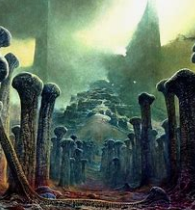

In [14]:
def statystyki(im):
    s = stat.Stat(im)
    print("extrema ", s.extrema)  # max i min
    print("count ", s.count)  # zlicza
    print("mean ", s.mean)  # srednia
    print("median ", s.median)  # mediana
    print("stddev ", s.stddev)  # odchylenie standardowe
    
mono1_png = Image.open("bek4.png")
mono1_png

In [15]:
statystyki(mono1_png)

extrema  [(0, 247), (0, 247), (0, 247)]
count  [40950, 40950, 40950]
mean  [90.97899877899877, 105.86031746031746, 92.09445665445665]
median  [76, 97, 81]
stddev  [67.79498469406941, 71.06439478047938, 56.32504103557847]


In [16]:
bek3 = Image.open("bek3.png")
statystyki(bek3)

extrema  [(0, 247), (0, 247), (1, 247)]
count  [34608, 34608, 34608]
mean  [54.67247457235322, 83.95246763754045, 97.8489944521498]
median  [47, 77, 92]
stddev  [42.661231962182455, 42.597990433670084, 38.98671892248308]


In [17]:
bek2 = Image.open("bek2.png")
statystyki(bek2)

extrema  [(0, 222), (6, 203), (16, 200)]
count  [36676, 36676, 36676]
mean  [77.7392300141782, 93.09406696477261, 97.54697895081252]
median  [70, 92, 97]
stddev  [42.632926469383555, 35.12812403760624, 27.43494076712233]


# Zad 6

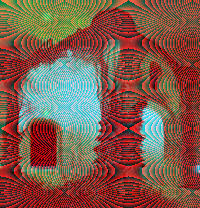

In [18]:
import numpy as np
from PIL import Image

def szary(w, h, a, b):
    return np.array([[(a * i ** 2 + b * j ** 2) % 256 for j in range(w)] for i in range(h)], dtype=np.uint8)

bek1_image = Image.open("bek1.png").convert("RGB")

width, height = bek1_image.size

gray_array = szary(width, height, a=3, b=-1)
gray_image = Image.fromarray(gray_array, mode="L")

r, g, b = bek1_image.split() 
new_image = Image.merge("RGB", (gray_image, g, b))  

new_image.save("mix.png")

new_image

# Zad 7

In [19]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Funkcja do wczytania obrazu i wyświetlenia histogramu kanałów R i G
def show_histogram(image_path):
    try:
        # Wczytanie obrazu
        image = Image.open(image_path)
        image = image.convert("RGB")  # Upewniamy się, że obraz jest w RGB

        # Rozdzielenie na kanały
        r, g, b = image.split()

        # Generowanie histogramów
        plt.figure(figsize=(10, 5))
        
        # Histogram dla kanału R
        plt.subplot(1, 2, 1)
        plt.hist(r.getdata(), bins=256, color='red', alpha=0.7)
        plt.title(f"Histogram kanału R: {os.path.basename(image_path)}")
        plt.xlabel("Intensywność")
        plt.ylabel("Liczba pikseli")

        # Histogram dla kanału G
        plt.subplot(1, 2, 2)
        plt.hist(g.getdata(), bins=256, color='green', alpha=0.7)
        plt.title(f"Histogram kanału G: {os.path.basename(image_path)}")
        plt.xlabel("Intensywność")
        plt.ylabel("Liczba pikseli")
        
        # Wyświetlenie histogramów
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Nie udało się przetworzyć obrazu {image_path}: {e}")

# Ścieżka do folderu z obrazami
folder_path = "sciezka/do/folderu/z/obrazami"

# Przetwarzanie wszystkich plików PNG w folderze
for file_name in os.listdir(folder_path):
    if file_name.endswith(".png"):
        image_path = os.path.join(folder_path, file_name)
        show_histogram(image_path)



FileNotFoundError: [WinError 3] The system cannot find the path specified: 'sciezka/do/folderu/z/obrazami'

# Zad 8

In [ ]:
bek2_png = Image.open("bek2.png")

bek3_png = Image.open("bek3.png")

bek1_png = Image.open("bek1.png")



In [ ]:
 from PIL import Image
import matplotlib.pyplot as plt


def pokaz_histogram_kanalow(image_path, image_name):
    """
    Показывает гистограммы каналов изображения.

    :param image_path: Путь к изображению.
    :param image_name: Название изображения.
    """
    # Загружаем изображение
    img = Image.open(image_path).convert("RGB")

    # Извлекаем гистограммы каналов
    histogram = img.histogram()
    r_hist = histogram[0:256]  # Канал R
    g_hist = histogram[256:512]  # Канал G
    b_hist = histogram[512:768]  # Канал B

    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.subplot(3, 1, 1)
    plt.bar(range(256), r_hist, color='red')
    plt.title(f"Histogram kanału R obrazu {image_name}")

    plt.subplot(3, 1, 2)
    plt.bar(range(256), g_hist, color='green')
    plt.title(f"Histogram kanału G obrazu {image_name}")

    plt.subplot(3, 1, 3)
    plt.bar(range(256), b_hist, color='blue')
    plt.title(f"Histogram kanału B obrazu {image_name}")

    plt.tight_layout()
    plt.show()


# Пример использования

In [ ]:
pokaz_histogram_kanalow("bek1.png", "bek1.png")

In [ ]:
pokaz_histogram_kanalow("bek2.png", "bek2.png")

In [ ]:
pokaz_histogram_kanalow("bek3.png", "bek3.png")

# Zad 9

In [ ]:
import numpy as np
from PIL import Image
from random import randint

def ukryj_kod(obraz, im_kod):
    t_obraz = np.asarray(obraz)
    t_kodowany = t_obraz.copy()
    h, w, d = t_obraz.shape
    t_kod = np.asarray(im_kod).astype(np.uint8)
    for i in range(h):
        for j in range(w):
            if t_kod[i, j] == 0:
                k = randint(0, 2)
                t_kodowany[i, j, k] = t_obraz[i, j, k] + 1
    return Image.fromarray(t_kodowany)

def odkryj_kod(obraz, zakodowany):
    t_obraz = np.asarray(obraz)
    t_zakodowany = np.asarray(zakodowany)
    h, w, d = t_obraz.shape
    t_kod = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if not np.array_equal(t_obraz[i, j], t_zakodowany[i, j]):
                t_kod[i, j] = 0  
            else:
                t_kod[i, j] = 255  
    return Image.fromarray(t_kod, mode="L")

batman_image = Image.open("batman2.png").convert("RGB")
zakodowany_image = Image.open("zakodowany2_2.png").convert("RGB")

im_kod = odkryj_kod(batman_image, zakodowany_image)

im_kod_array = np.asarray(im_kod)
black_pixels = np.sum(im_kod_array == 0)

im_kod.save("im_kod.png")

black_pixels, im_kod_path


In [ ]:
im_kod

In [20]:

def rysuj_ramke_kolor(w, h, grub, r, g, b):
    t = (h, w, 3)
    tab = np.ones(t, dtype=np.uint8) * 255 
    tab[grub:h-grub, grub:w-grub] = (r, g, b)  
    return tab

Image.fromarray(rysuj_ramke_kolor(120, 60, 10, 100, 200, 30)).show()